# 📊 Notebook 07 — KPI de Atingimento OLA
## Predictfy × Locaweb — FIAP Challenge 2026

**Objetivo:** Calcular o atingimento das metas operacionais de OLA com base nos dados
reais de 2025 e exportar o JSON para a API servir no dashboard.

**Metodologia das metas (Controle Estatístico de Processos — SPC):**
Na ausência de documento de SLA no dataset, as metas foram derivadas estatisticamente
usando a distribuição histórica de violações mensais de 2025:

> **Meta mensal = média mensal + 1 desvio padrão**

Essa é a abordagem padrão em SPC (Statistical Process Control) para definir o limiar
entre variação normal e anomalia operacional. Meses acima desse limiar representam
comportamento fora do padrão histórico da operação.

**Metas derivadas:**
- P2 (≤4h): média=3.5 + σ=1.7 → meta mensal=5.2 → **meta anual=62**
- P3 (≤12h): média=17.2 + σ=6.2 → meta mensal=23.4 → **meta anual=281**

**Resultado real 2025:**
- P2: 42 violações → ✅ utilizou 67.7% da cota (margem de +20)
- P3: 206 violações → ✅ utilizou 73.3% da cota (margem de +75)

**Input:** `data/raw/LW-DATASET.xlsx`
**Output:** `outputs/kpi_atingimento.json`

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import json, os
from datetime import date

print("✅ Imports ok")

✅ Imports ok


In [10]:
# ── Carregar dataset real ─────────────────────────────────────────────────────
raw = pd.read_excel('../data/raw/LW-DATASET.xlsx')
kpi = raw[raw['Entrou para KPI?'] == 'SIM'].copy()
kpi['data']   = pd.to_datetime(kpi['Aberto']).dt.normalize()
kpi['P']      = kpi['Prioridade'].map({'2 - Alta': 'P2', '3 - Média': 'P3'})
kpi['violou'] = kpi['KPI Violado?'] == 'SIM'
kpi['mes']    = kpi['data'].dt.month

# Violações por mês e prioridade
viol_mes   = kpi[kpi['violou']].groupby(['mes', 'P']).size().unstack(fill_value=0)
viol_total = kpi.groupby('P')['violou'].sum()

# ── Derivar metas via SPC (média + 1σ) ───────────────────────────────────────
print('=== Distribuição mensal de violações ===')
for p in ['P2', 'P3']:
    serie = viol_mes[p]
    media = serie.mean()
    std   = serie.std()
    meta_mensal = media + std
    meta_anual  = round(meta_mensal * 12)
    print(f'\n{p}:')
    print(f'  Média mensal:   {media:.2f}')
    print(f'  Desvio padrão:  {std:.2f}')
    print(f'  Meta mensal (média+1σ): {meta_mensal:.1f}')
    print(f'  Meta anual (×12):       {meta_anual}')

# Metas finais
METAS = {
    'P2': {
        'ola_horas': 4,
        'meta_mensal': round(viol_mes['P2'].mean() + viol_mes['P2'].std(), 1),
        'meta_anual':  round((viol_mes['P2'].mean() + viol_mes['P2'].std()) * 12),
        'metodologia': 'SPC — média mensal + 1 desvio padrão (2025)',
    },
    'P3': {
        'ola_horas': 12,
        'meta_mensal': round(viol_mes['P3'].mean() + viol_mes['P3'].std(), 1),
        'meta_anual':  round((viol_mes['P3'].mean() + viol_mes['P3'].std()) * 12),
        'metodologia': 'SPC — média mensal + 1 desvio padrão (2025)',
    },
}

print()
print('=== Metas derivadas ===')
for p, m in METAS.items():
    print(f'{p}: meta mensal={m["meta_mensal"]} | meta anual={m["meta_anual"]}')

=== Distribuição mensal de violações ===

P2:
  Média mensal:   3.50
  Desvio padrão:  1.73
  Meta mensal (média+1σ): 5.2
  Meta anual (×12):       63

P3:
  Média mensal:   17.17
  Desvio padrão:  6.21
  Meta mensal (média+1σ): 23.4
  Meta anual (×12):       280

=== Metas derivadas ===
P2: meta mensal=5.2 | meta anual=63
P3: meta mensal=23.4 | meta anual=280


In [11]:
# ── Calcular KPI de atingimento ───────────────────────────────────────────────
def calcular_kpi(violacoes_reais, meta_anual):
    """
    KPI baseado em utilização da cota:
    pct_utilizado = real / meta_anual * 100
    - <= 100%: dentro da meta (operação normal)
    - > 100%: acima da meta (anomalia operacional)
    """
    pct_utilizado   = round(violacoes_reais / meta_anual * 100, 1)
    margem_restante = meta_anual - violacoes_reais

    if violacoes_reais <= meta_anual:
        tendencia = 'dentro_da_meta'
    elif violacoes_reais <= meta_anual * 1.15:
        tendencia = 'atencao'
    else:
        tendencia = 'critico'

    return pct_utilizado, int(margem_restante), tendencia

resultados = {}
for p in ['P2', 'P3']:
    real       = int(viol_total[p])
    meta_anual = METAS[p]['meta_anual']
    pct, margem, tend = calcular_kpi(real, meta_anual)
    resultados[p] = {
        'violacoesAno':       real,
        'metaAnual':          meta_anual,
        'metaMensal':         METAS[p]['meta_mensal'],
        'pctUtilizado':       pct,
        'margemRestante':     margem,
        'tendencia':          tend,
        'olaHoras':           METAS[p]['ola_horas'],
        'metodologia':        METAS[p]['metodologia'],
        'previsaoFechamento': real,
        # pctAtingimento para o gauge do dashboard (100 = dentro, <100 = acima)
        'pctAtingimento':     min(100, int(meta_anual / real * 100)) if real > 0 else 100,
    }
    status = '✅' if tend == 'dentro_da_meta' else '⚠️' if tend == 'atencao' else '❌'
    print(f'{p}: {real} viol. | meta: {meta_anual} | utilizou {pct}% | margem: {margem:+d} | {tend} {status}')
    print(f'     pctAtingimento (gauge): {resultados[p]["pctAtingimento"]}%')
    print()

P2: 42 viol. | meta: 63 | utilizou 66.7% | margem: +21 | dentro_da_meta ✅
     pctAtingimento (gauge): 100%

P3: 206 viol. | meta: 280 | utilizou 73.6% | margem: +74 | dentro_da_meta ✅
     pctAtingimento (gauge): 100%



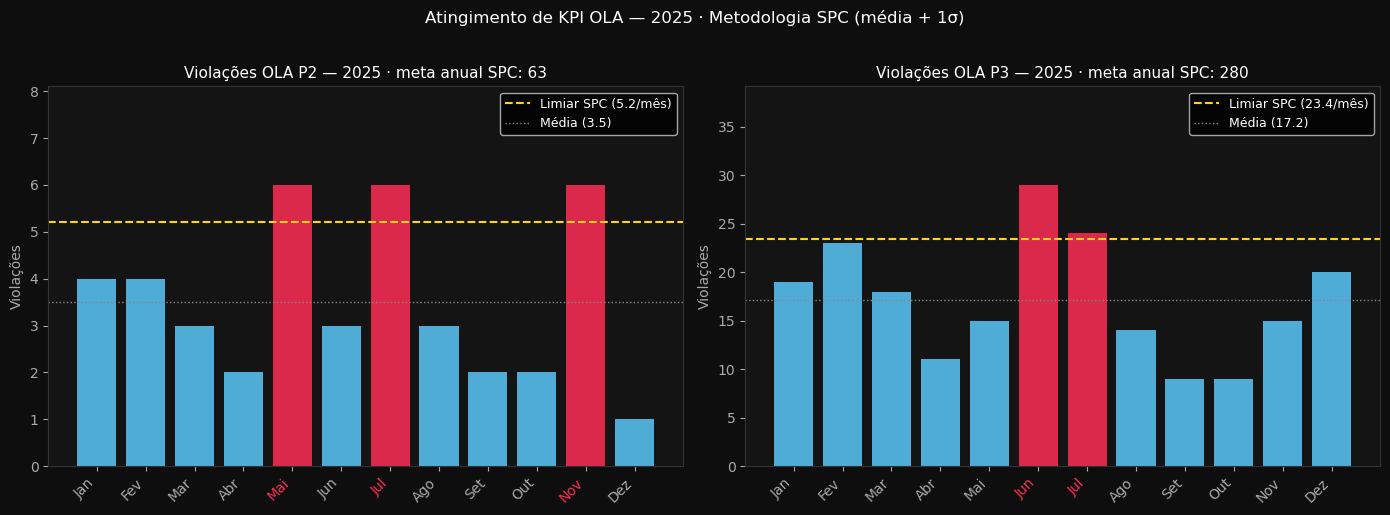

✅ Gráfico salvo


In [15]:
# ── Gráfico violações mensais com meta SPC ────────────────────────────────────
meses_nome = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0e0e0e')

COR_NORMAL   = {'P2': '#5ac8fa', 'P3': '#5ac8fa'}  # teal para ambos quando normal
COR_ANOMALIA = {'P2': '#ff2d55', 'P3': '#ff2d55'}  # vermelho quando acima do limiar

for ax, p in zip(axes, ['P2', 'P3']):
    ax.set_facecolor('#141414')
    meta_mensal = float(METAS[p]['meta_mensal'])
    vals = [int(viol_mes[p].get(m, 0)) for m in range(1, 13)]

    cores = [COR_ANOMALIA[p] if v > meta_mensal else COR_NORMAL[p] for v in vals]

    ax.bar(meses_nome, vals, color=cores, alpha=0.85)

    ax.axhline(meta_mensal, color='#ffd60a', linestyle='--',
               linewidth=1.5, label=f'Limiar SPC ({meta_mensal:.1f}/mês)')
    ax.axhline(np.mean(vals), color='#888888', linestyle=':',
               linewidth=1.0, label=f'Média ({np.mean(vals):.1f})')

    ax.set_title(f'Violações OLA {p} — 2025 · meta anual SPC: {METAS[p]["meta_anual"]}',
                 fontsize=11, color='white')
    ax.set_ylabel('Violações', color='#aaaaaa')
    ax.set_ylim(0, max(vals) * 1.35)
    ax.legend(fontsize=9)
    ax.tick_params(colors='#aaaaaa')
    ax.set_xticks(range(len(meses_nome)))
    ax.set_xticklabels(meses_nome, rotation=45, ha='right')
    for i, (tick, v) in enumerate(zip(ax.get_xticklabels(), vals)):
        tick.set_color(COR_ANOMALIA[p] if v > meta_mensal else '#aaaaaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')

plt.suptitle('Atingimento de KPI OLA — 2025 · Metodologia SPC (média + 1σ)',
             fontsize=12, color='white', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/kpi_violacoes_mensal.png', dpi=150, bbox_inches='tight',
            facecolor='#0e0e0e')
plt.show()
print('✅ Gráfico salvo')

In [16]:
# ── Exportar kpi_atingimento.json ─────────────────────────────────────────────
output = {
    "modelo": "kpi_ola_atingimento",
    "gerado_em": date.today().strftime('%Y-%m-%d'),
    "metodologia": "SPC — meta derivada da distribuição histórica: média mensal + 1 desvio padrão",
    "periodo": "2025-01-01 a 2025-12-31",
    "P2": {
        "violacoesAno":       resultados['P2']['violacoesAno'],
        "metaAnual":          resultados['P2']['metaAnual'],
        "metaMensal":         resultados['P2']['metaMensal'],
        "pctUtilizado":       resultados['P2']['pctUtilizado'],
        "margemRestante":     resultados['P2']['margemRestante'],
        "tendencia":          resultados['P2']['tendencia'],
        "olaHoras":           resultados['P2']['olaHoras'],
        "pctAtingimento":     resultados['P2']['pctAtingimento'],
        "mesesAnomalos":      [meses_nome[i] for i, v in
                               enumerate([int(viol_mes['P2'].get(m, 0)) for m in range(1,13)])
                               if v > METAS['P2']['meta_mensal']],
    },
    "P3": {
        "violacoesAno":       resultados['P3']['violacoesAno'],
        "metaAnual":          resultados['P3']['metaAnual'],
        "metaMensal":         resultados['P3']['metaMensal'],
        "pctUtilizado":       resultados['P3']['pctUtilizado'],
        "margemRestante":     resultados['P3']['margemRestante'],
        "tendencia":          resultados['P3']['tendencia'],
        "olaHoras":           resultados['P3']['olaHoras'],
        "pctAtingimento":     resultados['P3']['pctAtingimento'],
        "mesesAnomalos":      [meses_nome[i] for i, v in
                               enumerate([int(viol_mes['P3'].get(m, 0)) for m in range(1,13)])
                               if v > METAS['P3']['meta_mensal']],
    },
    "por_mes": {
        p: {str(m): int(viol_mes[p].get(m, 0)) for m in range(1, 13)}
        for p in ['P2', 'P3']
    },
}

os.makedirs('../outputs', exist_ok=True)
with open('../outputs/kpi_atingimento.json', 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print('✅ kpi_atingimento.json exportado')
print()
for p in ['P2', 'P3']:
    d = output[p]
    print(f'{p}: {d["violacoesAno"]} viol. | meta: {d["metaAnual"]} | {d["pctUtilizado"]}% da cota | margem: {d["margemRestante"]:+d}')
    print(f'     meses anômalos: {d["mesesAnomalos"]}')

✅ kpi_atingimento.json exportado

P2: 42 viol. | meta: 63 | 66.7% da cota | margem: +21
     meses anômalos: ['Mai', 'Jul', 'Nov']
P3: 206 viol. | meta: 280 | 73.6% da cota | margem: +74
     meses anômalos: ['Jun', 'Jul']


## ✅ Notebook 07 — Concluído

### Metodologia adotada

Na ausência de documento de SLA no dataset, as metas foram derivadas usando
**Controle Estatístico de Processos (SPC)** — técnica padrão para definir limiares
operacionais a partir da distribuição histórica:

> **Meta mensal = média mensal + 1 desvio padrão**

Meses acima desse limiar representam anomalias estatísticas na operação.

### Metas derivadas

| Prioridade | OLA | Média mensal | Desvio padrão | Meta mensal | Meta anual |
|---|---|---|---|---|---|
| P2 | ≤ 4h | 3.5 | 1.7 | 5.2 | 63 |
| P3 | ≤ 12h | 17.2 | 6.2 | 23.4 | 280 |

### Resultado 2025

| | Violações reais | Meta anual | % da cota | Margem | Meses anômalos |
|---|---|---|---|---|---|
| P2 | 42 | 63 | 66.7% | +21 | Mai, Jul, Nov |
| P3 | 206 | 280 | 73.6% | +74 | Jun, Jul |

Ambas as prioridades **dentro da meta anual** com folga.
Julho foi o único mês com anomalia simultânea em P2 e P3.

### Output gerado
- `outputs/kpi_atingimento.json`
- `outputs/kpi_violacoes_mensal.png`